<a href="https://colab.research.google.com/github/ASaragga/GRF/blob/main/ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import Pkg
Pkg.add(url="https://github.com/ASaragga/Caramel.jl")
Pkg.add("QuadGK")

using Caramel
using QuadGK
using Plots

    Updating git-repo `https://github.com/ASaragga/Caramel.jl`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


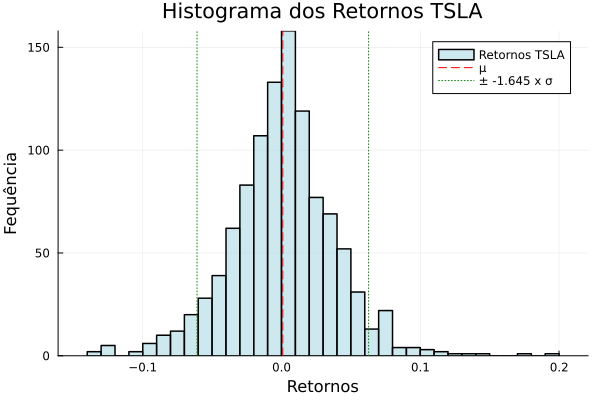

In [3]:
simbolo = "TSLA"
logr = LogReturn(simbolo, Date(2020,10,01),Date(2025,01,01)) |> DataFrame
returns = logr[:, :returns];

fig3 = histogram(returns,
          bins=30,  # Numero de barras
          color=:lightblue,
          label="Retornos $(simbolo)",
          xlabel="Retornos",
          ylabel="Fequência",
          title="Histograma dos Retornos $(simbolo)",
          grid=true,
          fillalpha=0.6,  # Transparencia das barras
          linecolor=:black,
          linewidth=1.5)

mu = mean(returns)
sigma = std(returns)
z = - 1.645

vline!([mu], linecolor=:red, linestyle=:dash, label="μ")
vline!([mu + z * sigma, mu - z * sigma],
       linecolor=:green, linestyle=:dot, label="± $(z) x σ")
display(plot!(fig3))

# Simulação Histórica

In [4]:
VaR1 = VaR(returns,0.05)
ETL1 = ETL(returns,0.05)
println("Simulação Histórica: VaR = ", VaR1, " e ETL = ", ETL1)

Simulação Histórica: VaR = 0.062893 e ETL = 0.08423003773584907


# Abordagem Paramética

$$\text{ETL}_\alpha = \mathbb{E}[X \mid X \leq \text{VaR}_\alpha] = - \mu + \sigma \, \frac{\phi(\Phi^{-1}(\alpha))}{\alpha}$$
onde
* $\phi(\cdot)$: é a função de densidade de probabilidade (PDF)
* $\Phi^{-1}(\cdot)$: é a função inversa da função de distribuição cumulativa (CDF)
* $\alpha$: é o nível de significância
* $\mu \approx 0$


# Normal

In [5]:
VaR2 = VaR(returns, 0.05, Normal())
ETL2 = ETL(returns, 0.05, Normal())
println("Abordagem Paramétrica (Normal): VaR = ", VaR2, " e ETL = ", ETL2)

Abordagem Paramétrica (Normal): VaR = 0.0618353534926267 e ETL = 0.07754402794027647


# T-Student(5)

In [7]:
VaR3 = VaR(returns, 0.05, TDist(5))
ETL3 = ETL(returns, 0.05, TDist(5))
println("Abordagem Paramétrica (T-Student(5)): VaR = ", VaR3, " e ETL = ", ETL3)

Abordagem Paramétrica (T-Student(5)): VaR = 0.07575216811280798 e ETL = 0.10864926951785285
